In [27]:


import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# CSV_PATH = "/users/aparasel/scratch/VvsLMem-Cntxt-Conflict/Scripts/FRQ/Corruption_Results/FRQ_headpatch_mockRAG_to_noRAG_qwen_celeb_vision.csv"
# df = pd.read_csv(CSV_PATH)

# # Ensure delta exists and is numeric: delta = patched - baseline
# if "delta" not in df.columns:
#     df["delta"] = pd.to_numeric(df["patched_logit_noRAG"], errors="coerce") - pd.to_numeric(df["baseline_logit_noRAG"], errors="coerce")
# else:
#     df["delta"] = pd.to_numeric(df["delta"], errors="coerce")

# df["layer"] = pd.to_numeric(df["layer"], errors="coerce").astype("Int64")
# df["head"]  = pd.to_numeric(df["head"],  errors="coerce").astype("Int64")

# df = df.dropna(subset=["delta", "layer", "head"])
# df.shape, df.columns

((168, 16),
 Index(['ID', 'Entity', 'Category', 'Group', 'Query', 'Mis_Knowledge_Key',
        'Parametric_ans', 'Contextual_ans', 'ctx_first_token_id', 'layer',
        'head', 'pos_src_count', 'pos_dst_count', 'baseline_logit_noRAG',
        'patched_logit_noRAG', 'delta'],
       dtype='object'))

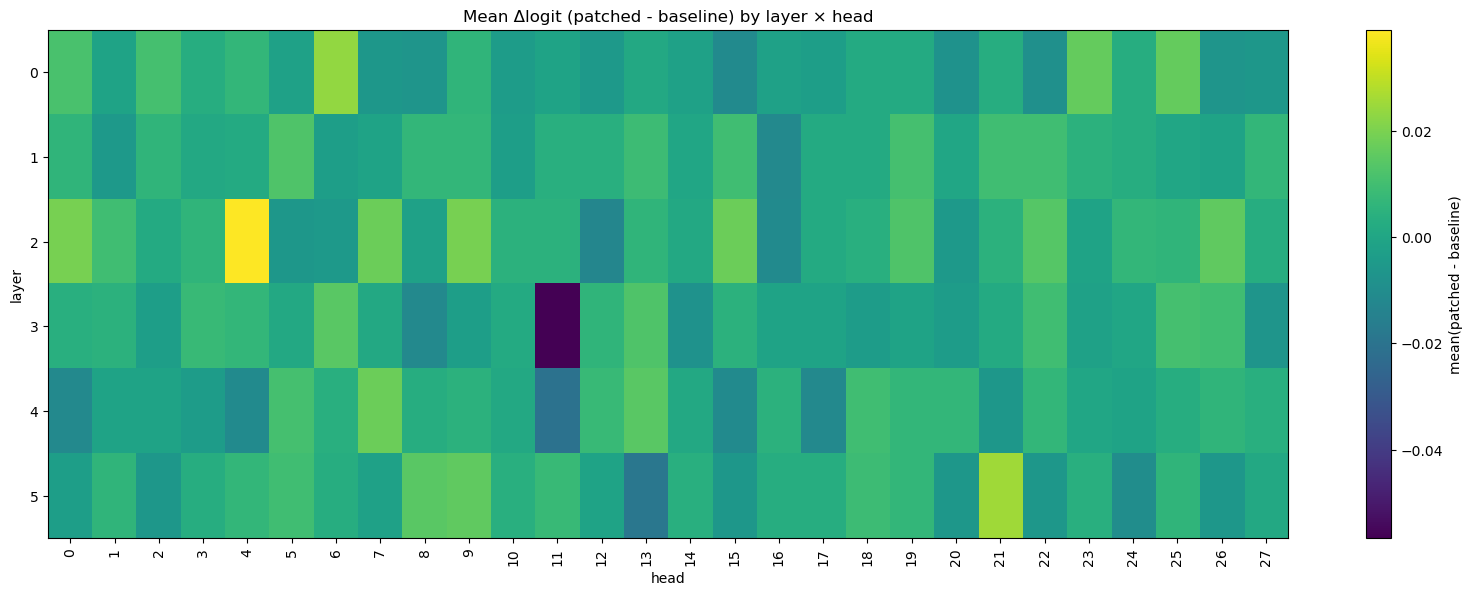

In [ ]:
# # 1) Heatmap: mean(delta) for each (layer, head)
# pivot = (
#     df.pivot_table(index="layer", columns="head", values="delta", aggfunc="mean")
#       .sort_index()
#       .sort_index(axis=1)
# )

# plt.figure(figsize=(min(20, 0.8 * pivot.shape[1] + 4), 0.6 * pivot.shape[0] + 3))
# plt.imshow(pivot.values, aspect="auto")
# plt.colorbar(label="mean(patched - baseline)")
# plt.title("Mean Δlogit (patched - baseline) by layer × head")
# plt.xlabel("head")
# plt.ylabel("layer")
# plt.xticks(np.arange(pivot.shape[1]), pivot.columns.tolist(), rotation=90)
# plt.yticks(np.arange(pivot.shape[0]), pivot.index.tolist())
# plt.show()

In [33]:
CSV_PATH = "/users/aparasel/scratch/VvsLMem-Cntxt-Conflict/Scripts/FRQ/Corruption_Results/FRQ_patch_full_mockRAG_to_noRAG_qwen_celeb_vision.csv"
CSV_PATH_2 = "/users/aparasel/scratch/VvsLMem-Cntxt-Conflict/Scripts/FRQ/Corruption_Results/FRQ_patch_full_mockRAG_to_noRAG_qwen_celeb_vision_pt2.csv"
df_1 = pd.read_csv(CSV_PATH)
df_2 = pd.read_csv(CSV_PATH_2)
df = pd.concat([df_1, df_2], ignore_index=True)
# # Ensure numeric
# df["baseline_logit_noRAG"] = pd.to_numeric(df.get("baseline_logit_noRAG"), errors="coerce")
# df["patched_logit_noRAG"]  = pd.to_numeric(df.get("patched_logit_noRAG"), errors="coerce")

# # score you want
# df["score"] = df["patched_logit_noRAG"] - df["baseline_logit_noRAG"]

# df["layer"] = pd.to_numeric(df.get("layer"), errors="coerce")
# df = df.dropna(subset=["layer", "score"])
# df["layer"] = df["layer"].astype(int)

# print("Rows:", len(df))
# print("Layers:", sorted(df["layer"].unique().tolist()))
# print("Columns:", list(df.columns))
df = df[df['Category'] == 'Career_error']
df = df[df['baseline_logit_noRAG'] < 7]

In [34]:
import numpy as np
import pandas as pd

key = ["Entity", "Category", "Mis_Knowledge_Key"]

# grab the one layer where it exists
mock = (
    df.loc[df["end_layer"].eq(21), key + ["logit_mockRAG"]]
      .dropna(subset=["logit_mockRAG"])
      .drop_duplicates(subset=key)
)

# merge it back; this creates logit_mockRAG_filled for every row
df = df.merge(mock, on=key, how="left", suffixes=("", "_from21"))

df["logit_mockRAG"] = df["logit_mockRAG"].fillna(df["logit_mockRAG_from21"])
df = df.drop(columns=["logit_mockRAG_from21"])

In [35]:
B = df["baseline_logit_noRAG"]
P = df["patched_logit_noRAG"]
M = df["logit_mockRAG"]

den = (M - B)
df["gap_closed"] = np.where(den.abs() > 1e-8, (P - B) / den, np.nan)

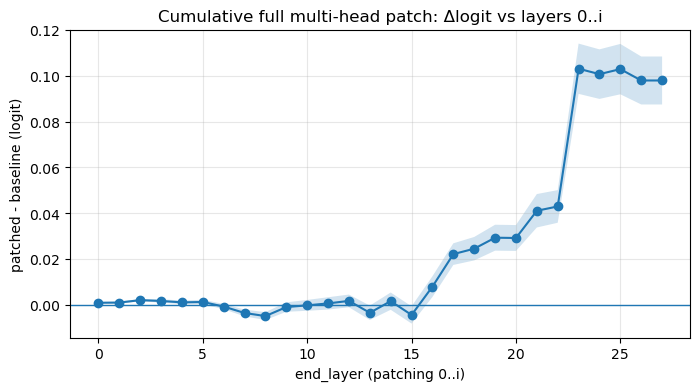

In [36]:
g = df.groupby("end_layer")["gap_closed"]

mean = g.mean().sort_index()
n = g.count().sort_index()
std = g.std(ddof=1).sort_index()
se = std / np.sqrt(n)
ci95 = 1.96 * se

plt.figure(figsize=(8,4))
plt.plot(mean.index, mean.values, marker="o")
plt.fill_between(mean.index, (mean-ci95).values, (mean+ci95).values, alpha=0.2)
plt.axhline(0, linewidth=1)

plt.title("Cumulative full multi-head patch: Δlogit vs layers 0..i")
plt.xlabel("end_layer (patching 0..i)")
plt.ylabel("patched - baseline (logit)")
plt.grid(True, alpha=0.3)
plt.show()

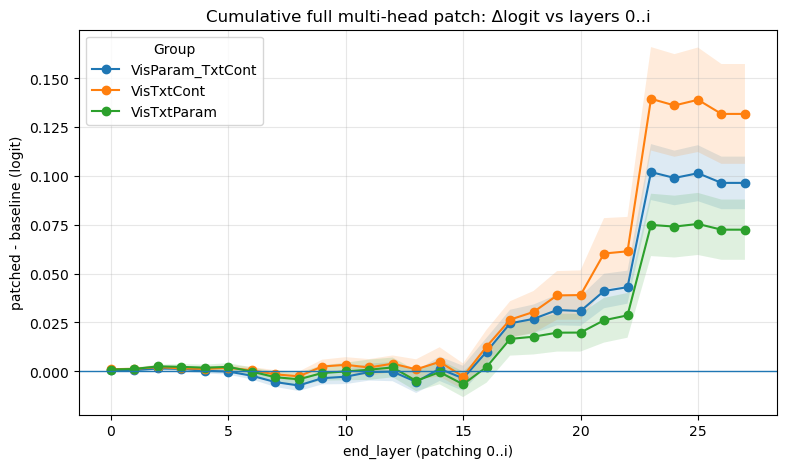

In [37]:
df = df[df['Group'] != 'VisCont_TxtParam']

plt.figure(figsize=(9,5))

for group_name, df_g in df.groupby("Group"):
    g = df_g.groupby("end_layer")["gap_closed"]

    mean = g.mean().sort_index()
    n = g.count().sort_index()
    std = g.std(ddof=1).sort_index()
    se = std / np.sqrt(n)
    ci95 = 1.96 * se

    # Line
    plt.plot(mean.index, mean.values, marker="o", label=group_name)

    # Confidence band
    plt.fill_between(
        mean.index,
        (mean - ci95).values,
        (mean + ci95).values,
        alpha=0.15
    )

plt.axhline(0, linewidth=1)
plt.title("Cumulative full multi-head patch: Δlogit vs layers 0..i")
plt.xlabel("end_layer (patching 0..i)")
plt.ylabel("patched - baseline (logit)")
plt.grid(True, alpha=0.3)
plt.legend(title="Group")
plt.show()